# Final Project

# **Topic**

**A Computational Linguistic Analysis of Female Genital Mutilation and Women’s Empowerment in Podcast Discourse: A Corpus-Based Analysis of The Story of Woman in Kenya**


This notebook is written as an interactive linguistic essay. It uses Markdown for explanaton, Python for analysis , and visualisations for evidence.

#**Research question**

What linguistic patterns characterize the discussion of female genital mutilation/cutting, trauma, and women's empowerment in the podcast *The Story of Woman in Kenya*?

#**Introduction**

Language plays a crucial role in shaping the public understanding of social issues. Podcast have become one of the most important media for discussing these complex topics and sharing personal experiences, providing a rich source of naturally occurring spoken discourse. One issue that has received growing international attention is female genital mutiliation/cutting (FGM/C), a practice that has affected millions of women and girls and raises important questions concerning health and human rights.

This project analyses the language of the podcast *The Story of Women in Kenya part 1: FGM/C and the Untapped Potential of Women*. The episode explores the experiences of women and girls affected by FGM/C, the role of communities and traditions, and the efforts undertaken by activists and organisations to promote education and social change.

Rather than comparing multiple texts, this study adopts a single-text corpus approach. The aim is to conduct a detailed linguistic analysis of how FGM/C and women’s empowerment are represented within this discourse. Using Natural Language Processing (NLP) techniques, the study examines lexical choices, grammatical patterns, named entities, sentiment, and recurring collocations in order to identify the dominant linguistic structures shaping the narrative.

By applying Natural Language Processing techniques to this transcrpit, this project aims to identify dominant themes, investigate emotional tone of the discourse, and examine how language is used to construct narratives of trauma and empowerment.

I expect this analysis to show that the lexical items relating, to women, girls, communities, education and empowerment will occur frequently throught this podcast episode.

Sentiment analysis is expected to reveal a neutral tone accompanied by both positive and negative elements.

Named Entity Recognition is expected to highlight references to geographical locations (particularly within Kenya), as well as individuals and organisations involved in advocacy and social change.

Finally, it is expected that the overall linguistic profile of the transcript will be action-oriented, with a relatively high frequency of verbs related to change, support, and intervention.

#**Dataset Description**


The dataset consists of a publicly available transcript of the podcast episode *The Story of Woman in Kenya part 1: FGM/C and The Untapped Potential of Women*. I use Beautiful Soap to scrape the webpage and extract paragraph text.

**Source**

The podcast transcript *The Story of Woman in Kenya part 1: FGM/C and The Untapped Potential of Women*

**Dataset unit**

One podcast episone transcript, divided into sentences and words

**Setup**

This code installs and imports the Python libraries used in the project. It also downloads the NLTK datasets needed for tokenisation, lemmatisation, part-of-speech tagging, named entity recognition, and sentiment analysis.

In [2]:
!pip -q install beautifulsoup4 requests nltk ipywidgets wordcloud

import re
import requests
import nltk
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from collections import Counter
from IPython.display import display, Markdown
import ipywidgets as widgets

from nltk import word_tokenize, sent_tokenize, pos_tag, ne_chunk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.text import Text
from nltk.collocations import BigramCollocationFinder, BigramAssocMeasures
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# Download required NLTK data.
downloads = [
    'punkt',
    'punkt_tab',
    'stopwords',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',
    'wordnet',
    'omw-1.4',
    'maxent_ne_chunker',
    'maxent_ne_chunker_tab',
    'words',
    'vader_lexicon'
]

for item in downloads:
    try:
        nltk.download(item, quiet=True)
    except Exception as error:
        print(f'Could not download {item}: {error}')

plt.style.use('seaborn-v0_8-whitegrid')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 44.8 MB/s eta 0:00:00


#**Methodology**

This project uses several basic NLP techniques:
- Tokenisation- splits the text into sentences and words
- Lemmatisation- reduces words to dictionary froms
- Part-of-Speech tagging- identifies nouns, verbs, adjectives, adverbs, and pronouns
- Named Entity Recognition- finds names of people, places and organisations
- Keyword Frequency Analysis- identifies repeated content words
- Sentiment Analysis- estimates emotional tone
- Collocations and n-gras- finds repeated word pairs
- Visualisations- present patterns using charts and a word cloud

The preprocessing steps are:
1. Scrape the webpage.
2. Extract paragraph text.
3. Remove extra whitespace and non-story material.
4. Tokenise the text.
5. Remove punctuation and stopwords when needed.
6. Apply linguistic analysis.

**Scraping the Website**
The code below donloads the transcript. Beautiful Soap then reads the HTML structure and extracts the paragraph text. The result is still raw text, so it may contain extra spaces or non-story material.

In [3]:
url = "https://thestoryofwomanpodcast.com/blog/the-story-of-woman-in-kenya-part-1-fgmc-and-the-untapped-potential-of-women"

response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

text = soup.get_text()

**Cleaning and Tokenising**

This code cleans the craped text by removing extra spaces and keeping mian story section. It then splits the text into sentences and words. This step creates the basic dataset that the rest of the analysis uses.

In [4]:
# remove extra whitespace
text = re.sub(r'\s+', ' ', text)

# remove non-letter characters (keeps spaces)
text_clean = re.sub(r'[^a-zA-Z\s]', '', text)

# lowercase everything
text_clean = text_clean.lower()

In [5]:
words = word_tokenize(text_clean)

In [6]:
sentences = sent_tokenize(text)

In [7]:
lemmatizer = WordNetLemmatizer()
lemmas = [lemmatizer.lemmatize(word) for word in words]

total_words = len(words)
unique_words = len(set(words))
unique_lemmas = len(set(lemmas))
lexical_diversity = unique_words / total_words
average_sentence_length = total_words / len(sentences)

summary_table = {
    'Total words': total_words,
    'Unique words': unique_words,
    'Unique lemmas': unique_lemmas,
    'Lexical diversity': round(lexical_diversity, 3),
    'Average sentence length': round(average_sentence_length, 2)
}

summary_table

{'Total words': 4244,
 'Unique words': 1025,
 'Unique lemmas': 948,
 'Lexical diversity': 0.242,
 'Average sentence length': 22.7}

#**Analysis and Results**

## Tokenisation and Lemmatisation

Tokenisation gives basic unit analysis: words and sentences. Lemmatisation is useful because it groups related form together.

In this project, lemmatisation gives slightly cleaner view of vocabulary size and because repeated grammatical forms are counted together.

#**Keyword frequency analysis**

The next step removes common stopwords such as *the, and, of*. This allows the analyss to focus on content words: words that carry meaning.

In [8]:
stop_words = set(stopwords.words('english'))
content_words = [w for w in lemmas if w not in stop_words and len(w) > 2]
word_counts = Counter(content_words)

word_counts.most_common(25)

[('community', 58),
 ('woman', 34),
 ('fgmc', 33),
 ('anna', 27),
 ('stoecklein', 27),
 ('one', 27),
 ('fgm', 23),
 ('practice', 22),
 ('story', 20),
 ('girl', 20),
 ('survivor', 19),
 ('kenya', 18),
 ('sean', 17),
 ('maasai', 15),
 ('also', 14),
 ('cut', 13),
 ('year', 13),
 ('different', 13),
 ('somali', 13),
 ('evelyn', 12),
 ('orchid', 12),
 ('callahagn', 12),
 ('research', 12),
 ('education', 12),
 ('wambui', 11)]

In [9]:
def plot_top_words(n=20):
    top_words = word_counts.most_common(n)
    labels = [item[0] for item in top_words]
    values = [item[1] for item in top_words]

    plt.figure(figsize=(12, 5))
    plt.bar(labels, values)
    plt.title(f'Top {n} Content Words')
    plt.xlabel('Word')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

widgets.interact(plot_top_words, n=widgets.IntSlider(value=20, min=5, max=40, step=5))

interactive(children=(IntSlider(value=20, description='n', max=40, min=5, step=5), Output()), _dom_classes=('w…

<function __main__.plot_top_words(n=20)>

In [10]:
top_keywords = word_counts.most_common(5)
keyword_text = ", ".join([f"**{word}** ({count})" for word, count in top_keywords])

display(Markdown(f"""
**Result-based interpretation:** The five most frequent content words are {keyword_text}.
"""))


**Result-based interpretation:** The five most frequent content words are **community** (58), **woman** (34), **fgmc** (33), **anna** (27), **stoecklein** (27). 


**Analysis**

These results suggest that the podcast constructs FGM/C as a social issue while grounding the discussion in personal narratives that humanise this topic.

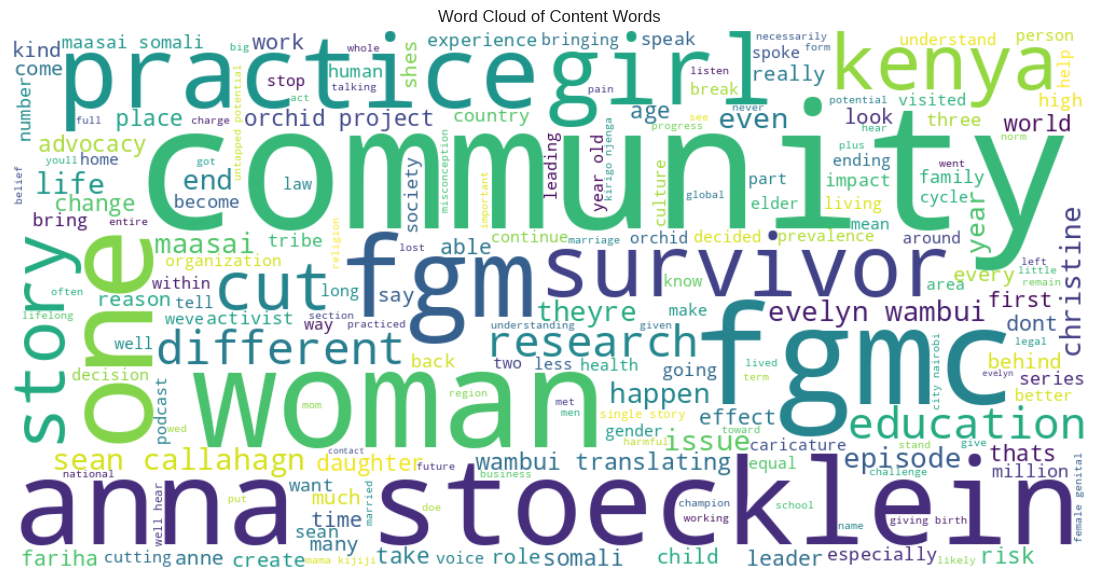

In [11]:
wordcloud_text = ' '.join(content_words)

cloud = WordCloud(width=1000, height=500, background_color='white', colormap='viridis').generate(wordcloud_text)

plt.figure(figsize=(14, 7))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Content Words')
plt.show()

The Word Cloud confirms the frequency table visually. However, the word cloud should be uses as a quick ovierview, while the bar char is better for exact comparison.

#**Sentence Length**



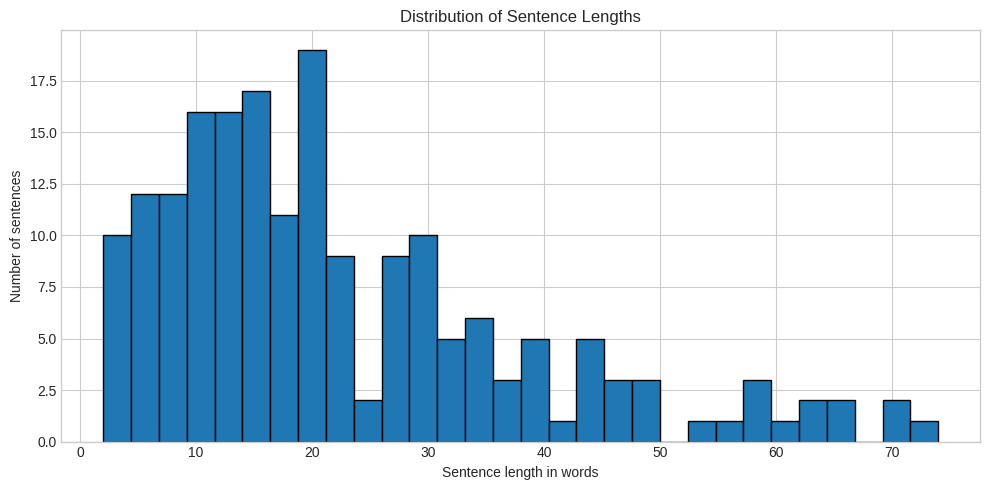

Empty sentence fragments removed: 0
Shortest sentence length: 2
Longest sentence length: 74
Average sentence length: 22.47


In [12]:
sentence_lengths = []
empty_sentence_fragments = 0

for sentence in sentences:
    sentence_words = [w for w in word_tokenize(sentence) if w.isalpha()]

    if len(sentence_words) > 0:
        sentence_lengths.append(len(sentence_words))
    else:
        empty_sentence_fragments += 1

plt.figure(figsize=(10, 5))
plt.hist(sentence_lengths, bins=30, edgecolor='black')
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Sentence length in words')
plt.ylabel('Number of sentences')
plt.tight_layout()
plt.show()

print('Empty sentence fragments removed:', empty_sentence_fragments)
print('Shortest sentence length:', min(sentence_lengths))
print('Longest sentence length:', max(sentence_lengths))
print('Average sentence length:', round(sum(sentence_lengths) / len(sentence_lengths), 2))


In [13]:
short_count = sum(1 for length in sentence_lengths if length <= 5)
long_count = sum(1 for length in sentence_lengths if length >= 30)
avg_len = sum(sentence_lengths) / len(sentence_lengths)

display(Markdown(f"""
**Result-based interpretation:** After removing **{empty_sentence_fragments}** empty fragment(s), the shortest real sentence length is **{min(sentence_lengths)} word(s)** and the longest is **{max(sentence_lengths)} words**. The average sentence length is **{avg_len:.2f} words**. There are **{short_count} very short sentences** of five words or fewer and **{long_count} long sentences** of thirty words or more.
"""))


**Result-based interpretation:** After removing **0** empty fragment(s), the shortest real sentence length is **2 word(s)** and the longest is **74 words**. The average sentence length is **22.47 words**. There are **15 very short sentences** of five words or fewer and **47 long sentences** of thirty words or more. 


**Analysis**

This sentence-length histogram shows the rhythym of the discussion. This distribution suggests a dynamic discourse in which extended explanatory structures are balanced with short statements to enhance clarity.

#**Part-of-Speech Tagging**

Part-of-speech tagging identifies grammatical categories. This helps categorize the text on it is dominated by nouns, verbs, adjectives, adverbs or other forms.

In [14]:
tagged_words = pos_tag(words)

def simplify_pos(tag):
    if tag.startswith('NN'):
        return 'Noun'
    if tag.startswith('VB'):
        return 'Verb'
    if tag.startswith('JJ'):
        return 'Adjective'
    if tag.startswith('RB'):
        return 'Adverb'
    if tag in ['PRP', 'PRP$']:
        return 'Pronoun'
    return 'Other'

simple_tags = [simplify_pos(tag) for word, tag in tagged_words]
pos_counts = Counter(simple_tags)
pos_counts

Counter({'Other': 1547,
         'Noun': 1066,
         'Adjective': 356,
         'Verb': 750,
         'Adverb': 255,
         'Pronoun': 270})

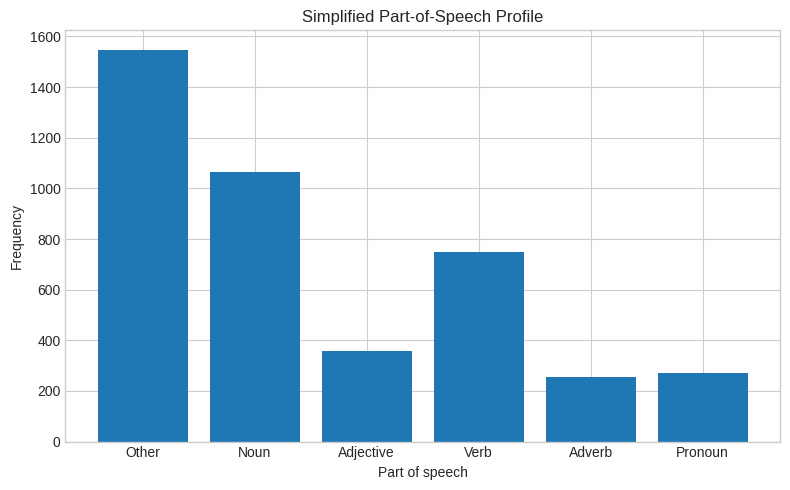

In [16]:
labels = list(pos_counts.keys())
values = list(pos_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title('Simplified Part-of-Speech Profile')
plt.xlabel('Part of speech')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [15]:
top_pos, top_pos_count = pos_counts.most_common(1)[0]
pos_summary = ", ".join([f"**{tag}**: {count}" for tag, count in pos_counts.most_common()])

display(Markdown(f"""
**Result-based interpretation:** The most common simplified part-of-speech category is **{top_pos}** with **{top_pos_count} examples**. The full simplified profile is: {pos_summary}. This helps describe the grammar of the text instead of only its vocabulary.
"""))


**Result-based interpretation:** The most common simplified part-of-speech category is **Other** with **1547 examples**. The full simplified profile is: **Other**: 1547, **Noun**: 1066, **Verb**: 750, **Adjective**: 356, **Pronoun**: 270, **Adverb**: 255. This helps describe the grammar of the text instead of only its vocabulary.


**Analysis**

The PoS category *Other* is the most common, that may suggest that the transcript contains many grammatical function words such as prepositions, conjunction, and determiners, which are essentail for connecting ideas and maintaining grammatical cohesion. This is characteristic of natural spoken language and reflect the explanatory nature of the podcast.

Among lexical categories, *nouns* and *verbs* appear the most often, indicating that the podcast focuses primarily on entities, concepts and practices related to FGM/C. This reflects the informational focus of the podcast. The high frequency of verbs indicate that the discussion is action-oriented. Meaning that speakers prefer refering to actions, processes, and change.

The smaller number of *adjectives* and *adverbs* suggests that the discourse is more informative and action-oriented than descriptive.

Overall, the grammatical profile supports the view that the podcast combines educational content with personal narratives.

#**Named Entity Recognition**

NER tries to fins proper nouns such as peaople, places and organisations.

In [19]:
# Clean the original 'text' specifically for NER, preserving capitalization
# Remove timestamps and optional section headers
ner_clean_text = re.sub(r'\[\d{2}:\d{2}:\d{2}\](?:\sSection: [^\]]+)?', '', text)
# Remove speaker names (e.g., 'Evelyn Wambui translating:', 'Anna Stoecklein:')
ner_clean_text = re.sub(r'\s*([A-Za-z]+(?: [A-Za-z]+)?(?: translating)?):', '', ner_clean_text)
# Remove excess whitespace
ner_clean_text = re.sub(r'\s+', ' ', ner_clean_text).strip()

# Tokenize and tag the NER-specific clean text
original_tokens = [word for word in word_tokenize(ner_clean_text) if word.isalpha()]
original_tagged = pos_tag(original_tokens)
entity_tree = ne_chunk(original_tagged)

entities = []
for subtree in entity_tree:
    if hasattr(subtree, 'label'):
        entity_name = ' '.join(token for token, tag in subtree.leaves())
        entity_label = subtree.label()
        entities.append((entity_name, entity_label))

entity_counts = Counter(entities)
entity_counts.most_common(20)

[(('FGMC', 'ORGANIZATION'), 24),
 (('FGM', 'ORGANIZATION'), 16),
 (('Kenya', 'GPE'), 14),
 (('Maasai', 'ORGANIZATION'), 9),
 (('Orchid Project', 'PERSON'), 6),
 (('Christine', 'PERSON'), 4),
 (('Fariha', 'PERSON'), 3),
 (('Kenya', 'PERSON'), 3),
 (('Nairobi', 'GPE'), 3),
 (('Somali', 'PERSON'), 3),
 (('Somali', 'GPE'), 3),
 (('Woman', 'GPE'), 2),
 (('Untapped Potential', 'ORGANIZATION'), 2),
 (('Maasai', 'GPE'), 2),
 (('Orchid', 'ORGANIZATION'), 2),
 (('Orchid', 'GPE'), 2),
 (('Sean', 'GPE'), 2),
 (('Anne', 'PERSON'), 2),
 (('Women Podcast The Story', 'PERSON'), 1),
 (('Woman Home Episodes Episode', 'PERSON'), 1)]

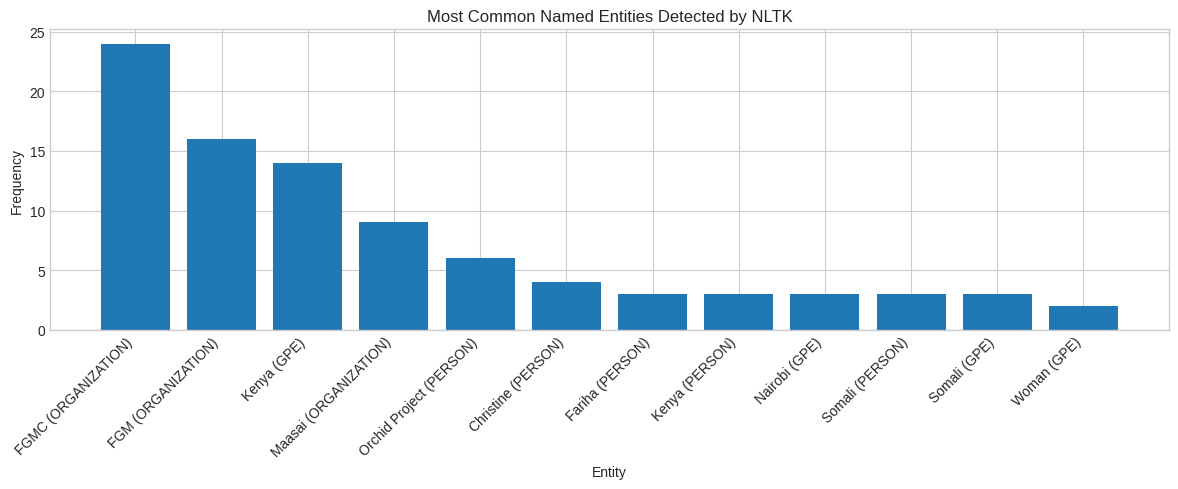

In [22]:
top_entities = entity_counts.most_common(12)
entity_labels = [f'{name} ({label})' for (name, label), count in top_entities]
entity_values = [count for (name, label), count in top_entities]

plt.figure(figsize=(12, 5))
plt.bar(entity_labels, entity_values)
plt.title('Most Common Named Entities Detected by NLTK')
plt.xlabel('Entity')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
if entity_counts:
    top_entities_text = ", ".join([f"**{name}** ({label}, {count})" for (name, label), count in entity_counts.most_common(5)])
    entity_interpretation = f"The most frequent named entities detected are {top_entities_text}."
else:
    entity_interpretation = "The NER tool did not detect many clear named entities."

display(Markdown(f"""
**Result-based interpretation:** {entity_interpretation}
"""))


**Result-based interpretation:** The most frequent named entities detected are **FGMC** (ORGANIZATION, 24), **FGM** (ORGANIZATION, 16), **Kenya** (GPE, 14), **Maasai** (ORGANIZATION, 9), **Orchid Project** (PERSON, 6).


**Analysis**

Named Entity Recognition demonstrates that the podcast is rooted in the Kenyan context and combines references to communities, organisations, and individuals. The most prominent are personal names and advocacy groups, whch may suggest that the discourse relies on storytelling, sharing experiences, and activism (*Orchid Project*). The concentration of geographical entities highlights the cultural specificity of the issue.

Several misclassifications (*FGMC* and *FGM* are labelled as organisations, while *Orchid Project* is identified as a person) reveal the limitations of automated NER systems and emphasise the need for human interpretation.

#**Collocations and N-grams**


In [23]:
finder = BigramCollocationFinder.from_words(content_words)
finder.apply_freq_filter(3)
bigram_measures = BigramAssocMeasures()

collocations = finder.nbest(bigram_measures.pmi, 20)
collocations

[('mama', 'kijiji'),
 ('female', 'genital'),
 ('kirigo', 'njenga'),
 ('giving', 'birth'),
 ('city', 'nairobi'),
 ('untapped', 'potential'),
 ('orchid', 'project'),
 ('evelyn', 'wambui'),
 ('wambui', 'translating'),
 ('well', 'hear'),
 ('year', 'old'),
 ('sean', 'callahagn'),
 ('single', 'story'),
 ('survivor', 'spoke'),
 ('anna', 'stoecklein'),
 ('old', 'survivor'),
 ('maasai', 'somali'),
 ('christine', 'year'),
 ('one', 'tribe'),
 ('sean', 'sean')]

In [24]:
collocation_text = ", ".join([f"**{' '.join(pair)}**" for pair in collocations[:8]])

display(Markdown(f"""
**Result-based interpretation:** Some of the strongest collocations are {collocation_text}. These word pairs are useful because they show repeated language patterns, not just individual frequent words.
"""))


**Result-based interpretation:** Some of the strongest collocations are **mama kijiji**, **female genital**, **kirigo njenga**, **giving birth**, **city nairobi**, **untapped potential**, **orchid project**, **evelyn wambui**. These word pairs are useful because they show repeated language patterns, not just individual frequent words.


In [25]:
common_bigrams = Counter(zip(content_words, content_words[1:])).most_common(20)
common_bigrams

[(('anna', 'stoecklein'), 27),
 (('sean', 'callahagn'), 12),
 (('evelyn', 'wambui'), 10),
 (('wambui', 'translating'), 9),
 (('orchid', 'project'), 8),
 (('woman', 'girl'), 5),
 (('story', 'fgmc'), 5),
 (('maasai', 'community'), 5),
 (('maasai', 'somali'), 5),
 (('somali', 'community'), 5),
 (('story', 'woman'), 4),
 (('girl', 'woman'), 4),
 (('year', 'old'), 4),
 (('different', 'community'), 4),
 (('single', 'story'), 4),
 (('fgmc', 'kenya'), 4),
 (('well', 'hear'), 4),
 (('untapped', 'potential'), 3),
 (('female', 'genital'), 3),
 (('giving', 'birth'), 3)]

In [26]:
bigram_text = ", ".join([f"**{' '.join(pair)}** ({count})" for pair, count in common_bigrams[:8]])

display(Markdown(f"""
**Result-based interpretation:** The most frequent bigrams include {bigram_text}.
"""))


**Result-based interpretation:** The most frequent bigrams include **anna stoecklein** (27), **sean callahagn** (12), **evelyn wambui** (10), **wambui translating** (9), **orchid project** (8), **woman girl** (5), **story fgmc** (5), **maasai community** (5).


**Analysis**

The collocationa nd bigram analyses provide insight into recurrent linguistic patterns.

Several collocations, such as *female genital*, *giving birth*, *untapped potential*, and *orchid project*, reflect the themes of the podcast. They demonstrate the repeated discussion of FGM/C, and showcase that broader aspects of women's health and experiences are taken into account.

The most frequent biagrams include *Anna Stoecklein*, *Sean Callaghan*, *Evelyn Eambui*, and *Wambui translating*. The prominence of thses names reflects the interview-based and narrative nature of the podcast.

Other biagrams, like *Orchid Project*, *Maasai community*, *woman girl*, and *story FGMC*, reinforce the advocacy, cultural context and experiences of the women and girls.

#**Sentiment Analysis**


Sentiment analysis estimates whether language sounds positive, negative, or neutral. This will help establish the overall sentiment of this podcast episode.

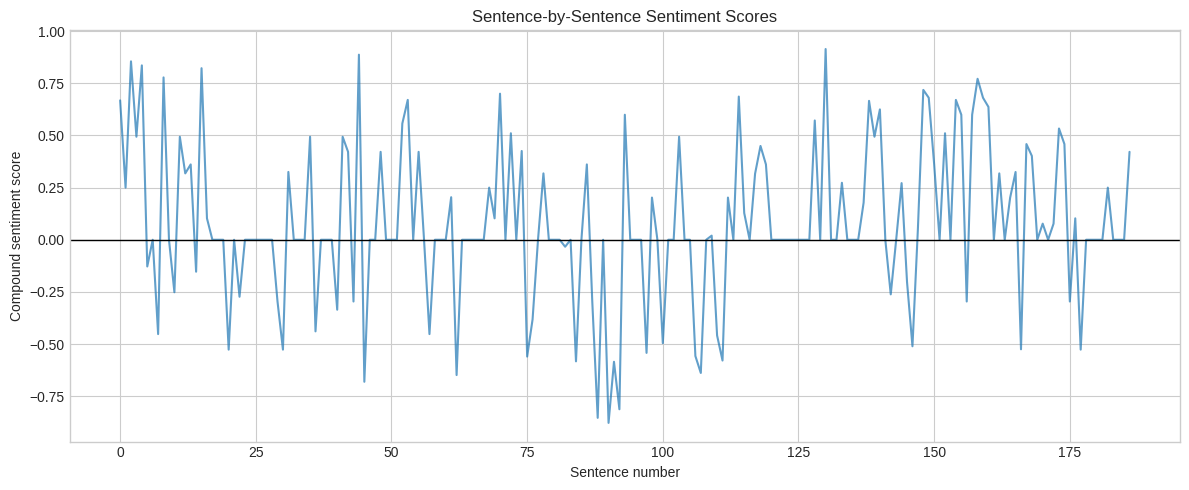

Average sentiment: 0.078
Most positive sentence: Each one of them shared their stories and how their personal experiences motivated them to become the activists and champions they are today, leading the charge in not only bringing this practice to an end, but also, as Christine puts it:[00:19:40] Christine: To see a world community where women and girls are free from harmful practices and all get equal opportunities to achieve their full potential.
Most negative sentence: From incredible pain and risk of infection at the time of the cut, to ongoing challenges with menses, recurring fistulas, painful and high risk pregnancies, and mental and emotional trauma, the list of health effects are long.Even a woman's ability to have her own family in the future can be impacted by something that happened to her in her youth.


In [27]:
sentiment_analyzer = SentimentIntensityAnalyzer()

sentiment_scores = [sentiment_analyzer.polarity_scores(sentence)['compound'] for sentence in sentences]

plt.figure(figsize=(12, 5))
plt.plot(sentiment_scores, alpha=0.7)
plt.axhline(0, color='black', linewidth=1)
plt.title('Sentence-by-Sentence Sentiment Scores')
plt.xlabel('Sentence number')
plt.ylabel('Compound sentiment score')
plt.tight_layout()
plt.show()

print('Average sentiment:', round(sum(sentiment_scores) / len(sentiment_scores), 3))
print('Most positive sentence:', sentences[sentiment_scores.index(max(sentiment_scores))])
print('Most negative sentence:', sentences[sentiment_scores.index(min(sentiment_scores))])

In [29]:
average_sentiment = sum(sentiment_scores) / len(sentiment_scores)
positive_count = sum(1 for score in sentiment_scores if score > 0.05)
negative_count = sum(1 for score in sentiment_scores if score < -0.05)
neutral_count = len(sentiment_scores) - positive_count - negative_count

display(Markdown(f"""
**Result-based interpretation:** The average sentiment score is **{average_sentiment:.3f}**. The analysis finds **{positive_count} positive**, **{negative_count} negative**, and **{neutral_count} neutral** sentences.
"""))


**Result-based interpretation:** The average sentiment score is **0.078**. The analysis finds **68 positive**, **35 negative**, and **84 neutral** sentences. 


**Analysis**

The sentiment analysis indicates a slightly positive overall emotional tone. Although the podcast addresses a highly sensitive topic, the discourse is not negative. The emotional profile appears to be balanced.

The prominence of neutral sentences suggests that the episode's main function is informative and educational.

The higher number of positive sentences indicates that the discussion puts emphasis on advocacy, empowerment, and future changes, which can be supported by the most positive sentence identified in the analysis.

In contrast, the most negative sentence describes the physical and psychological consequences of FGM/C.

Overall, the sentiment analysis supports the expectation that the podcast is mainly neutral or slightly more positive.

#**Conclusion**

This analysis has examined how language constructs narratives of trauma, community, and empowerment in a single podcast episode devoted to female genital mutilation/cutting in Kenya. By applying a range of NLP techniques to the transcript of *The Story of Woman in Kenya Part 1: FGM/C and the Untapped Potential of Women*, the study has identified concrete, measurable patterns in the discourse.

The results largely confirmed the expectations set out at the beginning of the project. The most frequent content words: *community*, *woman*, *FGM/C*, *girl*, and *education*, reveal a discourse that is simultaneously activist and human-centred. Rather than framing FGM/C as an abstract policy problem, the podcast situates it within specific social relationships, lived experiences, and community structures. The prominence of proper names such as Anna Stoecklein, Evelyn Wambui, and the Orchid Project further reinforces this: the episode builds its authority not through statistics alone, but through personal testimony and named advocacy.

The sentiment analysis revealed a score of just +0.078, confirming the prediction of an overall neutral tone with both positive and negative elements. What is perhaps more revealing than the average, however, is the emotional range the transcript covers. The most negative sentence describes the physical and psychological consequences of FGM/C with clinical precision, while the most positive captures the vision of a world where women and girls are entirely free from harmful practices. The podcast holds both of these registers simultaneously.

The part-of-speech analyis adds futher to this project. Nouns were the dominant category, followed closely by verbs, which suggests a discourse that is as concerned with naming and describing the problem as it is with prescribing action.

Of course, this analysis has significant limitations. It is based on a single transcript, which means no comparative claims can be made. The NLP tools used, particularly VADER for sentiment and NLTK's NER system, were designed for different genres of text, and their errors — most notably the misclassification of FGM/C as an organisation — are a reminder that automated analysis always requires human interpretation.

Nevertheless, what this project demonstrates is that computational linguistics can be a genuinely useful complement to traditional textual analysis, particularly for spoken discourse that might otherwise be difficult to study systematically. By making the lexical and grammatical patterns of this podcast visible and measurable, the analysis reveals something that is easy to intuit but hard to prove: that the language of advocacy is carefully and purposefully constructed.